## Read in data

In [ ]:
import pandas as pd

df = pd.read_csv('263_1.txt', header=None)
# df = pd.read_csv('capture.csv', header=None)
# df.columns = (['Time(s)', 'Xacc(g)', 'Yacc(g)', 'Zacc(g)'])
df.columns = (['Z_front(g)', 'Z_rear(g)'])
# display(df)
print(df.shape)

# df_rear = pd.read_csv('front.csv', header=None)
# # df_rear.columns = (['Time(s)', 'Xacc(g)', 'Yacc(g)', 'Zacc(g)'])
# df_rear.columns = (['Time(s)', 'Zacc(g)'])
# print(df_rear.shape)
# display(df_rear)

(90980, 2)


## Define filter function

In [4]:
import numpy as np
from scipy import signal

# params: Sampled data; Cutoff frequency in Hz; Sampling rate in Hz; Filter order
def hpf(data, cutoff_freq, Fs, order):
    # Design the high-pass filter (change btype to 'highpass')
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = signal.butter(order, normal_cutoff, btype='highpass')  # <-- modify here

    # Sample data (with time vector)
    # t = np.linspace(0, 1, 1000)  # Time vector for 1 second signal
    # data = np.sin(2*np.pi*150*t) + np.random.rand(1000)  # Example signal with noise

    # Apply the filter
    return signal.filtfilt(b, a, data)

## Analyze data and Plotting

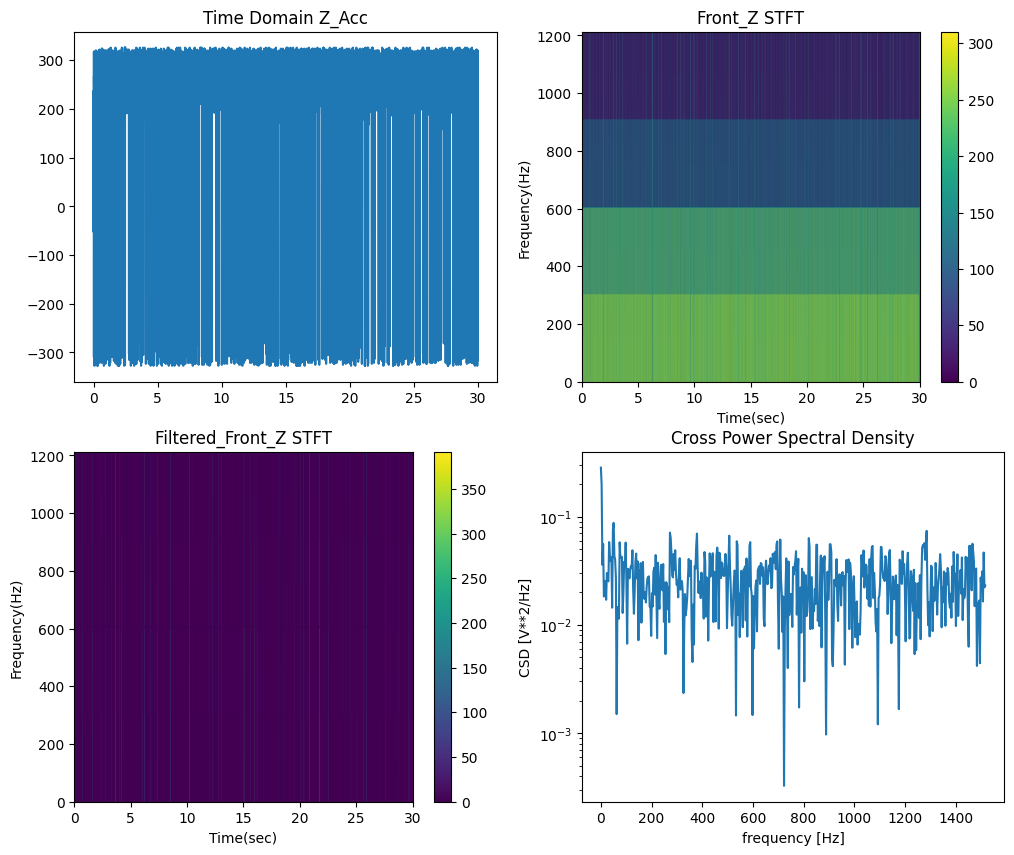

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import datetime

# parameters
N = df.shape[0] # number of samples
Fs = N / 30 # sampling rate
T = 1 / Fs  # Sampling interval
t = np.arange(0, 30, T)  # Time vector (1 second)
# d = Fs/N # freqeuncy spacing of FFT

# axis
# time_axis = df['Time(s)']
freqs_axis = np.fft.fftfreq(N, T)

# Front acc 
front_zacc = df['Z_front(g)'] # z-axis acceleration of front one
fft_front = np.fft.fft(front_zacc) # FFT of original front z-axis
front_magnitude = np.abs(fft_front)

# filter low frequency of the signal
front_zacc_filtered = hpf(front_zacc, 50, Fs, 3)

# FFT of filtered signals
fft_filtered_front = np.fft.fft(front_zacc_filtered)
filtered_abs = np.abs(fft_filtered_front)

# Rear acc
rear_zacc = df['Z_rear(g)'] # z-axis acceleration of rear one
fft_rear = np.fft.fft(rear_zacc) # FFT of original rear z-axis
rear_magnitude = np.abs(fft_rear)

# filter low frequency of the signal
front_zacc_filtered = hpf(front_zacc, 50, Fs, 3)
rear_zacc_filtered = hpf(rear_zacc, 50, Fs, 3)

# FFT of filtered signals
fft_filtered_front = np.fft.fft(front_zacc_filtered)
filtered_abs_front = np.abs(fft_filtered_front)
fft_filtered_rear = np.fft.fft(rear_zacc_filtered)
filtered_abs_rear = np.abs(fft_filtered_rear)

# plot the signals
fig = plt.figure(figsize=(12, 10))  # Adjust the width and height as needed
plt.subplot(221)
plt.plot(t, front_zacc)
plt.title('Time Domain Z_Acc')


# Short Time Fourier Transform of the signals
f, t, zfront_stft = signal.stft(front_zacc, Fs, nperseg=5)
f_filterd, t_filtered, zfront_stft_filtered = signal.stft(front_zacc_filtered, Fs, nperseg=5)

plt.subplot(222)
plt.pcolormesh(t, f, np.abs(zfront_stft), vmin=0, shading='gouraud')
plt.title('Front_Z STFT')
plt.xlabel('Time(sec)')
plt.ylabel('Frequency(Hz)')
plt.colorbar()

plt.subplot(223)
plt.pcolormesh(t_filtered, f_filterd, np.abs(zfront_stft_filtered), vmin=0, shading='gouraud')
plt.title('Filtered_Front_Z STFT')
plt.xlabel('Time(sec)')
plt.ylabel('Frequency(Hz)')
plt.colorbar()

plt.subplot(224)
plt.title('Cross Power Spectral Density')
f, Pxy = signal.csd(front_zacc, rear_zacc, Fs, nperseg=1024) # Cross power spectral by Welch's method
plt.semilogy(f, np.abs(Pxy))
plt.xlabel('frequency [Hz]')
plt.ylabel('CSD [V**2/Hz]')
plt.show()


plt.tight_layout(rect=[0, 0.5, 1, 0.5])
plt.show()

## Define 1-D TDOA function

In [ ]:
def compute_1d_tdoa(source, receiver1, receiver2, speed_of_sound=343):
    """
    Compute the TDOA (Time Difference of Arrival) in 1D.

    Parameters:
    - source: Scalar position of the sound source (e.g., x-coordinate).
    - receiver1: Scalar position of the first receiver (e.g., x-coordinate).
    - receiver2: Scalar position of the second receiver (e.g., x-coordinate).
    - speed_of_sound: Speed of sound in m/s (default is 343 m/s).

    Returns:
    - tdoa: Time difference of arrival in seconds.
    """
    # Calculate distances from the source to each receiver
    distance1 = abs(source - receiver1)
    distance2 = abs(source - receiver2)

    # Compute TDOA
    tdoa = (distance2 - distance1) / speed_of_sound
    
    return tdoa

# Example usage
source_position = 10  # Position of the source (e.g., 10 meters)
receiver1_position = 2  # Position of the first receiver
receiver2_position = 20  # Position of the second receiver
tdoa = compute_1d_tdoa(source_position, receiver1_position, receiver2_position)
print(f"TDOA: {tdoa:.6f} seconds")
